**Initialize**

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

col = ['time', 'long', 'x', 'y', 'z']
r_k = pd.read_csv('KAMOOALEWA.aei', sep='\s+', skiprows=4, names=col)
r_f = pd.read_csv('2023FW13.aei', sep='\s+', skiprows=4, names=col)
r_e = pd.read_csv('EARTHMOO.aei', sep='\s+', skiprows=4, names=col)

**ICRF**

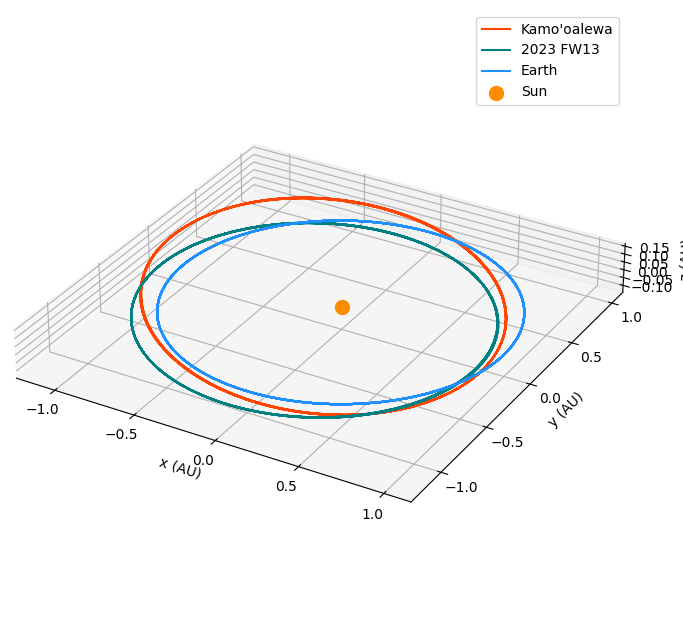

In [25]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(r_k['x'], r_k['y'], r_k['z'], label='Kamo\'oalewa', color='orangered')
ax.plot(r_f['x'], r_f['y'], r_f['z'], label='2023 FW13', color='teal')
ax.plot(r_e['x'], r_e['y'], r_e['z'], label='Earth', color='dodgerblue')
ax.scatter([0], [0], [0], color='darkorange', s=100, label='Sun')

ax.set_aspect('equal')
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.set_zlabel('z (AU)')
ax.legend()
ax.grid(True)
plt.show()

**Earth-centric coordinates**

In [28]:
theta = np.arctan2(r_e['y'], r_e['x'])

x_rot_k = r_k['x'] * np.cos(theta) + r_k['y'] * np.sin(theta) - (r_e['x'] * np.cos(theta) + r_e['y'] * np.sin(theta))
y_rot_k = -r_k['x'] * np.sin(theta) + r_k['y'] * np.cos(theta) - (-r_e['x'] * np.sin(theta) + r_e['y'] * np.cos(theta))
z_rot_k = r_k['z'] - r_e['z']

x_rot_f = r_f['x'] * np.cos(theta) + r_f['y'] * np.sin(theta) - (r_e['x'] * np.cos(theta) + r_e['y'] * np.sin(theta))
y_rot_f = -r_f['x'] * np.sin(theta) + r_f['y'] * np.cos(theta) - (-r_e['x'] * np.sin(theta) + r_e['y'] * np.cos(theta))
z_rot_f = r_f['z'] - r_e['z']

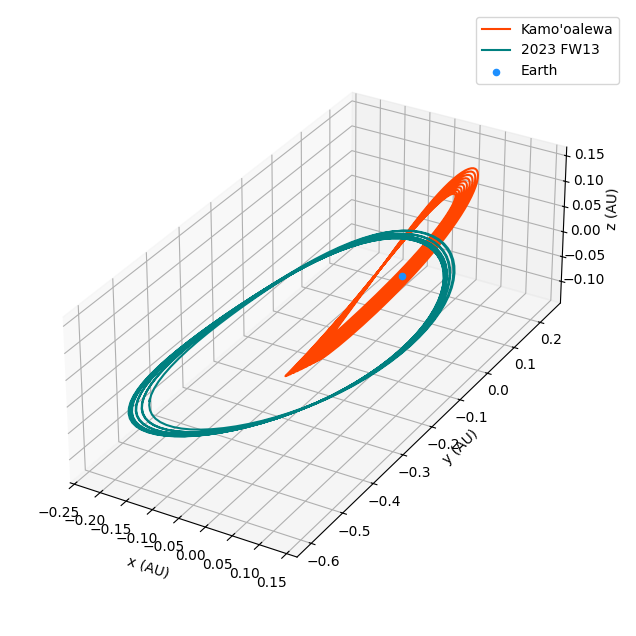

In [40]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot(x_rot_k, y_rot_k, z_rot_k, label='Kamo\'oalewa', color='orangered')
ax.plot(x_rot_f, y_rot_f, z_rot_f, label='2023 FW13', color='teal')
ax.scatter(0, 0, 0, label='Earth', color='dodgerblue')

ax.set_aspect('equal')
ax.set_xlabel('x (AU)')
ax.set_ylabel('y (AU)')
ax.set_zlabel('z (AU)')
ax.legend()
ax.grid(True)
plt.show()

**HORIZONS Data**

In [37]:
from astroquery.jplhorizons import Horizons
import numpy as np

start_jd = 2458400.5
duration_yrs = 50
epochs = start_jd + np.arange(0, duration_yrs * 365.25, 150)

obj_kam = Horizons(id='469219', location='@sun', epochs=epochs)
vec_kam = obj_kam.vectors()

obj_ear = Horizons(id='3', location='@sun', epochs=epochs)
vec_ear = obj_ear.vectors()

k_real_x, k_real_y = np.array(vec_kam['x']), np.array(vec_kam['y'])
e_real_x, e_real_y = np.array(vec_ear['x']), np.array(vec_ear['y'])

theta_real = np.arctan2(e_real_y, e_real_x)

k_real_x_rot = k_real_x * np.cos(theta_real) + k_real_y * np.sin(theta_real)
k_real_y_rot = -k_real_x * np.sin(theta_real) + k_real_y * np.cos(theta_real)

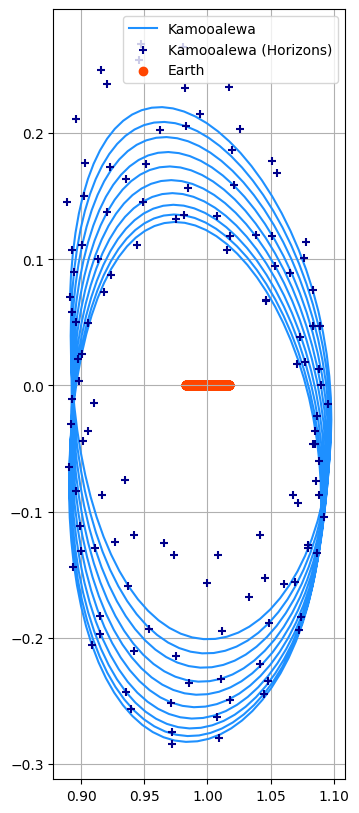

In [38]:
plt.figure(figsize=(10, 10))

plt.plot(kam_x_rot, kam_y_rot, label='Kamooalewa', color='dodgerblue')
plt.scatter(k_real_x_rot, k_real_y_rot, label='Kamooalewa (Horizons)', color='darkblue', marker='+', s=30, zorder=5)
plt.scatter(ear_x_rot, ear_y_rot, label='Earth', color='orangered')

plt.gca().set_aspect('equal')
plt.legend()
plt.grid(True)
plt.show()